In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt


from dataset.radio_galaxy_dataset.firstgalaxydata import FIRSTGalaxyData
from helpers import first_radio_galaxy_transform_val

In [9]:
ds = FIRSTGalaxyData(
    root=str("data"), selected_split="test",
    selected_classes=["FRI", "FRII", "Compact", "Bent"],
    input_data_list=["galaxy_data_h5.h5"],
    is_PIL=False, is_RGB=True,
    transform=first_radio_galaxy_transform_val,
)
raw = np.asarray(ds[120], dtype=np.float32)
img01 = (raw + 1) / 2
x = torch.from_numpy(img01).float()
F = torch.fft.fftshift(torch.fft.fft2(x))

In [3]:
def conj_partner(S):
    return torch.roll(torch.flip(S, dims=(-2, -1)), shifts=(1, 1), dims=(-2, -1))

def make_hermitian_or(S):
    S = torch.fft.ifftshift(S)
    return torch.fft.fftshift(torch.logical_or(S > 0, conj_partner(S) > 0).float())

def make_hermitian_and(S):
    S = torch.fft.ifftshift(S)
    return torch.fft.fftshift(torch.logical_and(S > 0, conj_partner(S) > 0).float())

In [15]:
M = torch.from_numpy(np.load("uv_coverages/VLA_mask_150.npy")).float()

def recon(mask):
    return torch.fft.ifft2(torch.fft.ifftshift(mask * F))

def imag_ratio(r):
    return (r.imag.pow(2).mean().sqrt() / r.real.pow(2).mean().sqrt()).item()

variants = {
    "BASE": M,
    "OR": make_hermitian_or(M),
    "AND": make_hermitian_and(M),
}

for name, mask in variants.items():
    r = recon(mask)
    print(f"{name:10s} kept={int((mask > 0).sum()):5d} max_imag = {r.imag.max()} max_real= {r.real.max()}")

BASE       kept= 2852 max_imag = 0.05498487874865532 max_real= 0.2905501425266266
OR         kept= 4675 max_imag = 1.8539100921088902e-08 max_real= 0.4789574444293976
AND        kept= 1029 max_imag = 5.395605295888117e-09 max_real= 0.10959853231906891


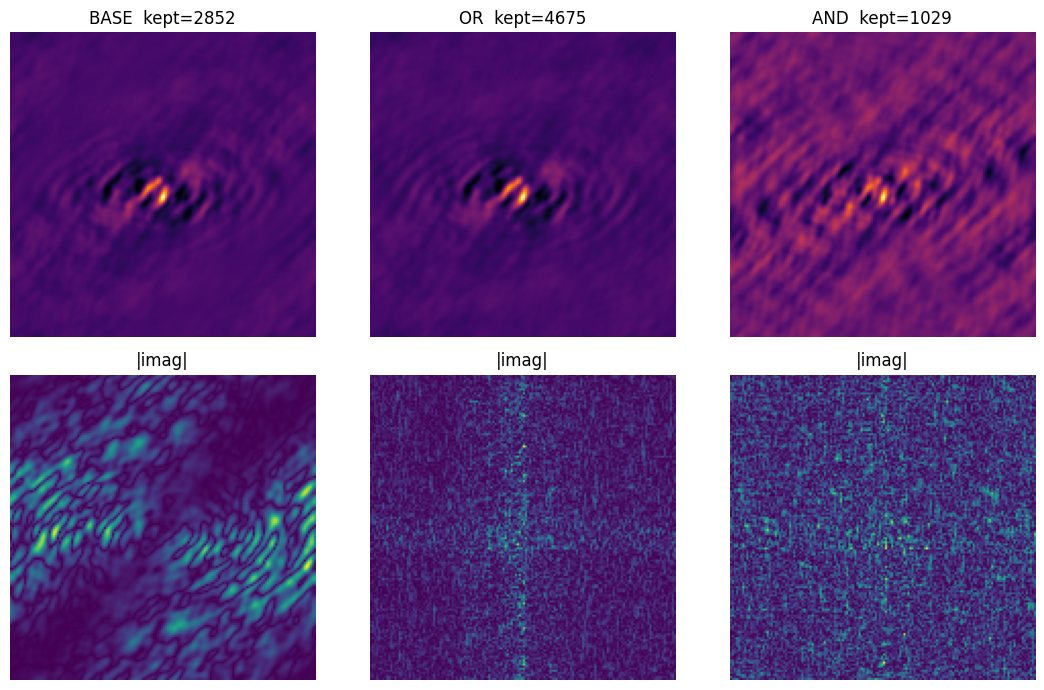

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for j, (name, mask) in enumerate(variants.items()):
    r = recon(mask)
    axes[0, j].imshow(r.real.numpy(), cmap="inferno")
    axes[0, j].set_title(f"{name}  kept={int((mask > 0).sum())}")
    axes[0, j].axis("off")
    axes[1, j].imshow(r.imag.abs().numpy(), cmap="viridis")
    axes[1, j].set_title(f"|imag|")
    axes[1, j].axis("off")
plt.tight_layout()
plt.show()

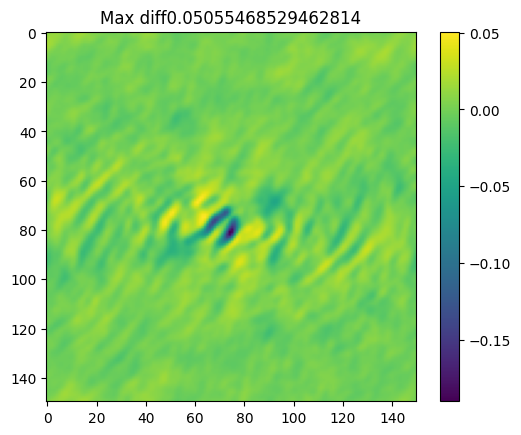

In [23]:
r_base = recon(M)
r_OR = recon(make_hermitian_or(M))
plt.imshow(r_base.real.numpy()-r_OR.real.numpy())
plt.title(f"Max diff{(r_base.real.numpy()-r_OR.real.numpy()).max()}")
plt.colorbar()
plt.show()